Name: Sana Raza

Labpartner(s):  Taherunnesa Rahi

In [49]:
#import statements go here
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

**For today's lab you need to install the package cartopy**

In [2]:
# you can install packages here in a notebook with pip or conda, 
# or in the anaconda navigator in the environments tab (reccommended)
%pip install cartopy
%pip install netCDF4

# conda install cartopy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
# I had an old version of cartopy so I had to upgrade:
# pip install --upgrade cartopy

In [50]:
import cartopy.crs as ccrs   #import map styles/types
import cartopy.feature as cfeature  # features such as the ocean, coastlines rivers, etc

# Class 6.2

Today we will finish fiunction sharing and do more plotting

# Warmups 6.2

**W.1** Write some code that generates 15 random integers from 1-100. If the integers are divisible by 2 assign them to list "x" if they are divisible by three, assign them to list "y", if they are neither assign them to list "z". 

In [51]:
import numpy as np

random_integers = np.random.randint(1, 101, size=15)  

# Filter arrays using NumPy masks
x = random_integers[random_integers % 2 == 0]                                # divisible by 2
y = random_integers[random_integers % 3 == 0]                                # divisible by 3
z = random_integers[(random_integers % 2 != 0) & (random_integers % 3 != 0)]  # neither

print('Generated numbers:', random_integers)
print('Divisible by 2:', x)
print('Divisible by 3:', y)
print('Neither:', z)

Generated numbers: [32 77 69 60 54 11 22 33  8 99 60 55 65 29 73]
Divisible by 2: [32 60 54 22  8 60]
Divisible by 3: [69 60 54 33 99 60]
Neither: [77 11 55 65 29 73]


# Lecture 6.2

### Agenda:

- Show us your functions
- Questions
- Cartopy!

### Show us your functions (from Lab 5.2) - continued

### Questions

### Cartopy

Let's take the data we used last time and make the plot publication ready

There are a number of differnt map projections available in Cartopy.  
https://cartopy.readthedocs.io/stable/reference/projections.html
Robinson is often used for global maps

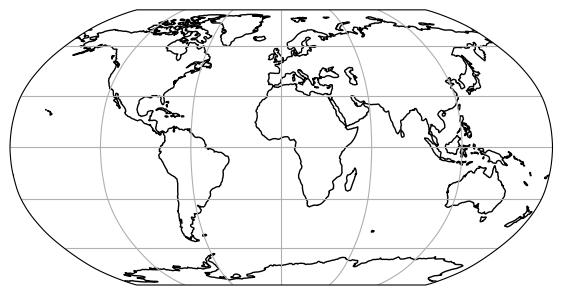

In [53]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson())
ax.coastlines(resolution='110m')
ax.gridlines()

When we are plotting ocean data, we like to make the Pacific contiguous, let's rotate

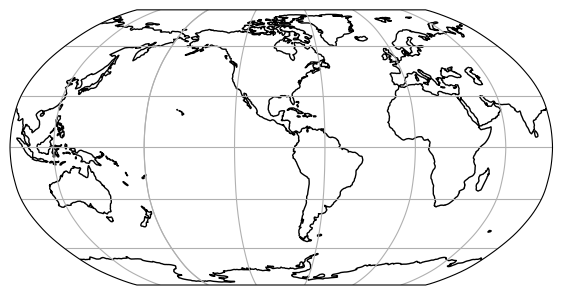

In [54]:
# plot a basic map with no data, rotated
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson(central_longitude = 360-89)) # this rotates the map to 203 degrees East
ax.coastlines(resolution='110m')
ax.gridlines()

Or we can rotate it so that it cuts through Indonesia (not good for mangrove or coral work)

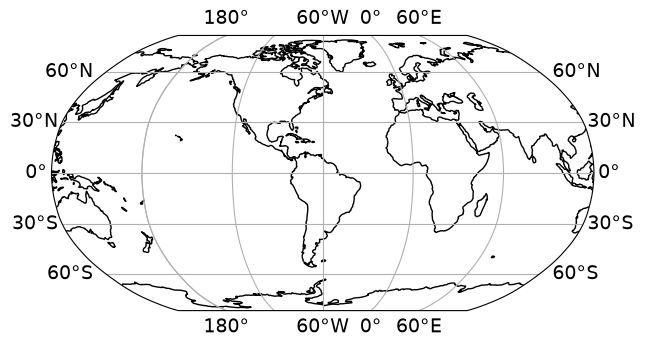

In [55]:
# plot a basic map with no data, rotated
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson(central_longitude = -60))
# -60 (60 W) is the same as 300 E (360 degrees in total 360-60W = 300E)
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True) # let's add some labels


Let's try some different map projections

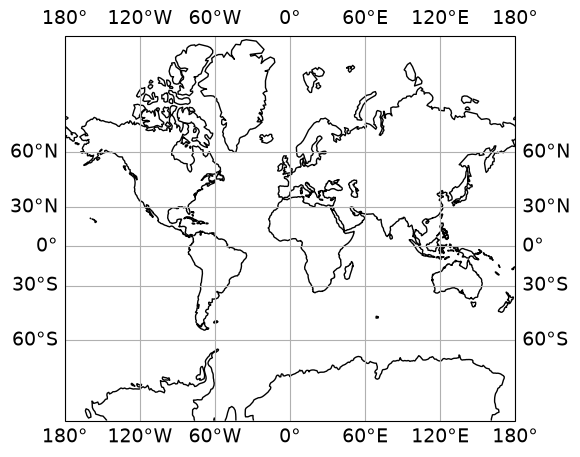

In [56]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Mercator()) # different map projection
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True)

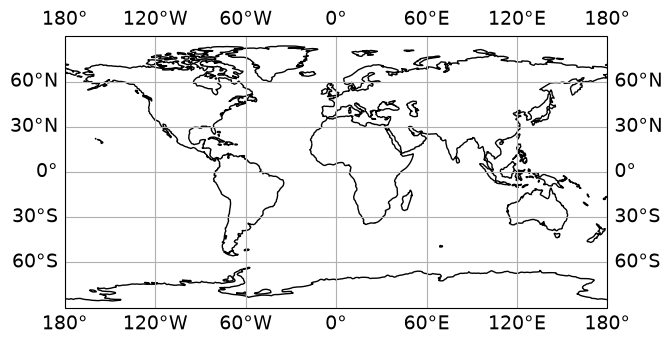

In [57]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True)


How do I zoom in?

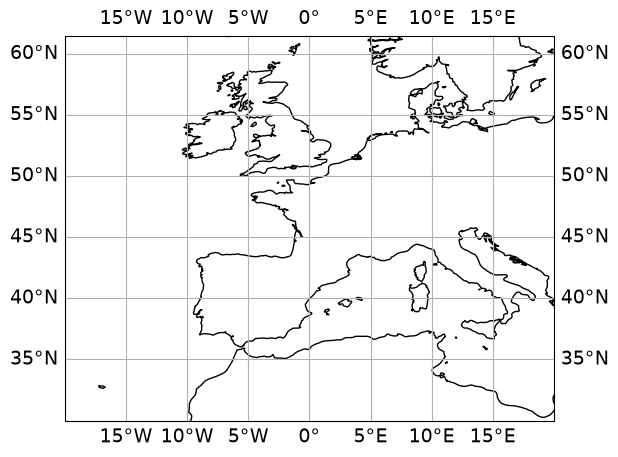

In [58]:
# let's zoom in to S Asia
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-20, 20, 30, 60]) 
ax.coastlines(resolution='50m') # zoom in then need more resolution
ax.gridlines(draw_labels=True)


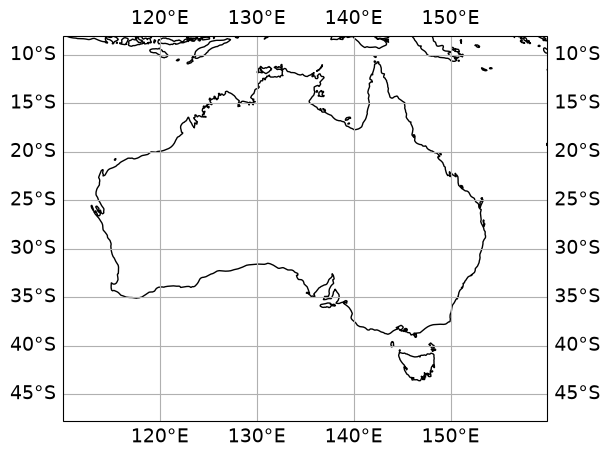

In [59]:
# make a plot of Australia

plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([110, 160, -8, -45]) # set the limits of the plot
ax.coastlines(resolution='50m')
ax.gridlines(draw_labels=True)

#### Moving back to the Gulf of Mexico, we want to set the lat and lon range to match our HYCOM data. How do we find this?

In [60]:
#insert path or url to file here
# download from the internet:
link = "https://tds.hycom.org/thredds/dodsC/datasets/GOMe0.04/expt_03.9/data/archive/2026/039_archv.2026_001_00_2d.nc"

In [61]:
gom_data = xr.open_dataset(link, decode_times=False)

In [62]:
gom_data.Date

<xarray.DataArray 'Date' (MT: 1)> Size: 8B
[1 values with dtype=float64]
Coordinates:
  * MT       (MT) float64 8B 4.566e+04
    Date     (MT) float64 8B ...
Attributes:
    units:           day as %Y%m%d.%f
    C_format:        %13.4f
    FORTRAN_format:  (f13.4)
    long_name:       date
    _ChunkSizes:     512

In [63]:
gom_data.MT

<xarray.DataArray 'MT' (MT: 1)> Size: 8B
array([45657.])
Coordinates:
  * MT       (MT) float64 8B 4.566e+04
    Date     (MT) float64 8B ...
Attributes:
    long_name:    time
    units:        days since 1900-12-31 00:00:00
    calendar:     gregorian
    axis:         T
    _ChunkSizes:  512

In [64]:
gom_data

<xarray.Dataset> Size: 5MB
Dimensions:                (MT: 1, Latitude: 385, Longitude: 525)
Coordinates:
  * MT                     (MT) float64 8B 4.566e+04
    Date                   (MT) float64 8B ...
  * Latitude               (Latitude) float32 2kB 18.09 18.13 ... 31.93 31.96
  * Longitude              (Longitude) float32 2kB -98.0 -97.96 ... -77.04
Data variables:
    surface_e_stress       (MT, Latitude, Longitude) float32 808kB ...
    surface_n_stress       (MT, Latitude, Longitude) float32 808kB ...
    ssh                    (MT, Latitude, Longitude) float32 808kB ...
    u_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    v_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    mixed_layer_thickness  (MT, Latitude, Longitude) float32 808kB ...
Attributes:
    Conventions:                     CF-1.6
    title:                           HYCOM
    source:                          HYCOM archive file
    experiment:                      01.4
    history:                         archv2ncdf2d
    comment:                         p-grid
    DODS_EXTRA.Unlimited_Dimension:  MT

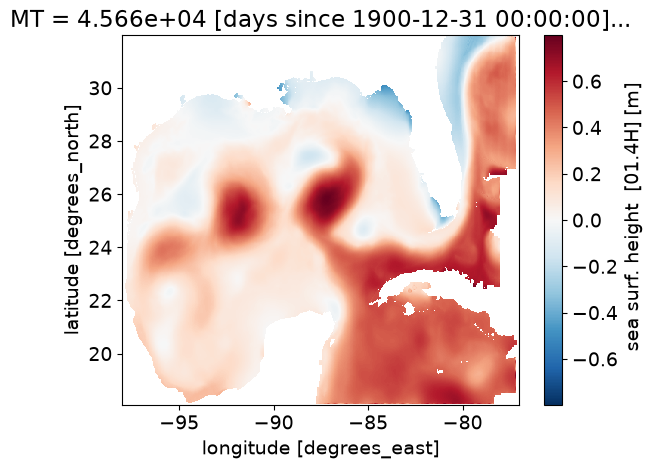

In [65]:
# let's remember what our data looked like, pick a variable to plot

gom_data.ssh.plot()

I'm going to get the max and min of the lat and lon to help me plot the data

In [66]:
lat_min = gom_data.Latitude.min()
print(lat_min)

<xarray.DataArray 'Latitude' ()> Size: 4B
array(18.091648, dtype=float32)
Attributes:
    standard_name:  latitude
    units:          degrees_north
    axis:           Y


In [67]:
lat_max = gom_data.Latitude.max()
print(lat_max)

<xarray.DataArray 'Latitude' ()> Size: 4B
array(31.960648, dtype=float32)
Attributes:
    standard_name:  latitude
    units:          degrees_north
    axis:           Y


In [68]:
lon_min = gom_data.Longitude.min()
print(lon_min)

<xarray.DataArray 'Longitude' ()> Size: 4B
array(-98., dtype=float32)
Attributes:
    standard_name:  longitude
    units:          degrees_east
    point_spacing:  even
    axis:           X


In [69]:
lon_max = gom_data.Longitude.max()
print(lon_max)

<xarray.DataArray 'Longitude' ()> Size: 4B
array(-77.03998, dtype=float32)
Attributes:
    standard_name:  longitude
    units:          degrees_east
    point_spacing:  even
    axis:           X


Now I can use them below

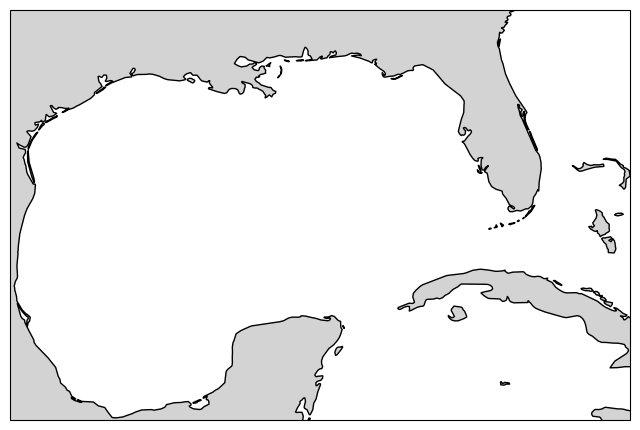

In [70]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 
# note the seqence of arguments for set_extent: x1, x2, y1, y2

#Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='lightgrey')
# you can use named colors: https://matplotlib.org/stable/gallery/color/named_colors.html
# or with other methods: https://matplotlib.org/stable/users/explain/colors/colors.html

ax.add_feature(land_50m)

#### Let's make the land color a bit lighter gray

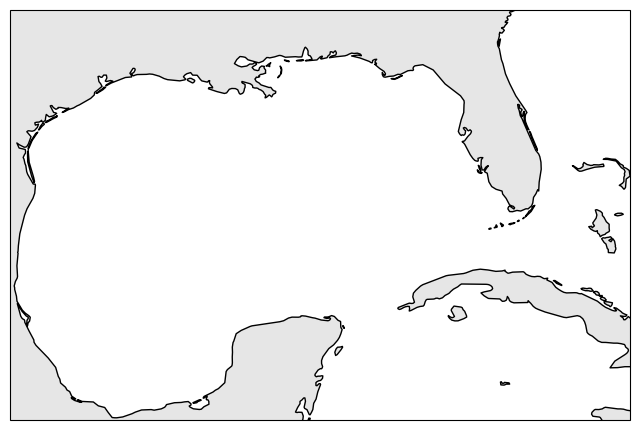

In [71]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 
# note the seqence of arguments for set_extent: x1, x2, y1, y2

#Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9') # 0 is black and 1 is white
# you can use named colors: https://matplotlib.org/stable/gallery/color/named_colors.html
# or with other methods: https://matplotlib.org/stable/users/explain/colors/colors.html

ax.add_feature(land_50m)

#### Now let's add some data

In [72]:
# lets figure out what var is

var = gom_data.ssh[0,:,:] # get rid of the time dimension
var

<xarray.DataArray 'ssh' (Latitude: 385, Longitude: 525)> Size: 808kB
[202125 values with dtype=float32]
Coordinates:
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
    MT         float64 8B 4.566e+04
    Date       float64 8B ...
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]
    _ChunkSizes:    [  1 385 525]

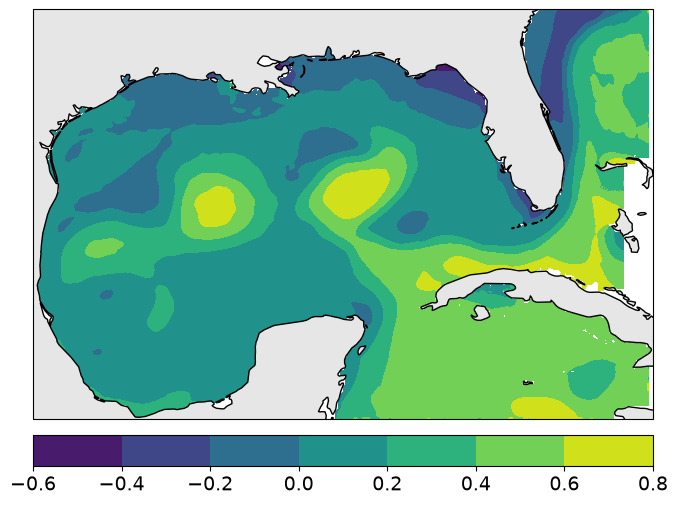

In [73]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 

# Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9')
ax.add_feature(land_50m)

# let's fill in the following:
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# Contours the data on tho the map projection
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree()) # projection is needed in every plot call

# Creates colorbar based on the contour. This allows us to get a quick look at our data range 
# before we start formatting the figure 
cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)
#cbar = plt.colorbar(p, orientation='horizontal')
#cbar = plt.colorbar(p)


#### Try taking out the options for the colorbar, what happens? What does "pad" do?

#### What is the range of our data?

In [74]:
print(var.max())

<xarray.DataArray 'ssh' ()> Size: 4B
array(0.7986358, dtype=float32)
Coordinates:
    MT       float64 8B 4.566e+04
    Date     float64 8B ...
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]
    _ChunkSizes:    [  1 385 525]


In [75]:
print(var.min())

<xarray.DataArray 'ssh' ()> Size: 4B
array(-0.504511, dtype=float32)
Coordinates:
    MT       float64 8B 4.566e+04
    Date     float64 8B ...
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]
    _ChunkSizes:    [  1 385 525]


#### Let's set the countour levels to match our data range. I'm also going to change the colormap
See https://matplotlib.org/stable/users/explain/colors/colormaps.html
Note you can reverse any colormap by appending '_r' to the name

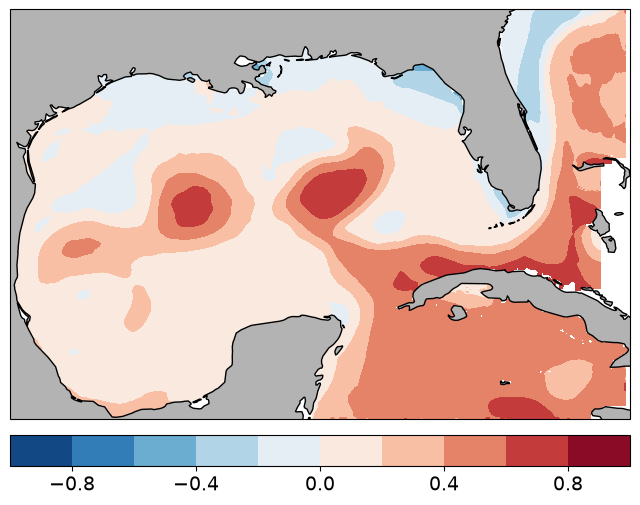

In [76]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)

# let's fill in the following:
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# let's fill in the range here:
step = np.arange(-1, 1.1, 0.2)  # start, stop, step
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'RdBu_r', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)


#### Okay, now let's add some labels

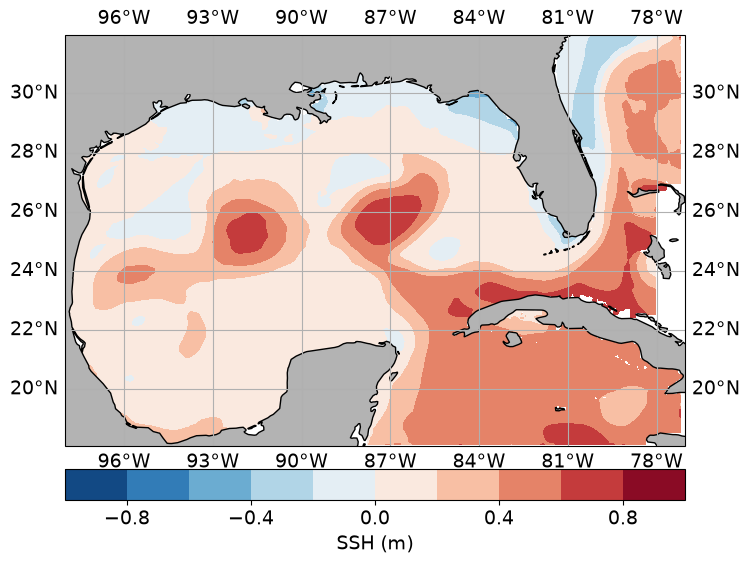

In [77]:
# copy in previous code here
# I'm also going to cut out the white bits at right by adjusting lon_max

fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)

# let's fill in the following:
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# let's fill in the range here:
step = np.arange(-1, 1.1, 0.2)  # start, stop, step
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'RdBu_r', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.03)

cbar.set_label("SSH" +' (m)', size = 14)

ax.gridlines(draw_labels=True)


#### These labels are too small for what I want. I need them to be much bigger.

In [78]:
#Note we can easily make the lat/lon and colorbar font size bigger by adjusting the matplotlib parameters, 
# which I introduced last time
import matplotlib as mpl
mpl.rcParams['font.size'] = 14

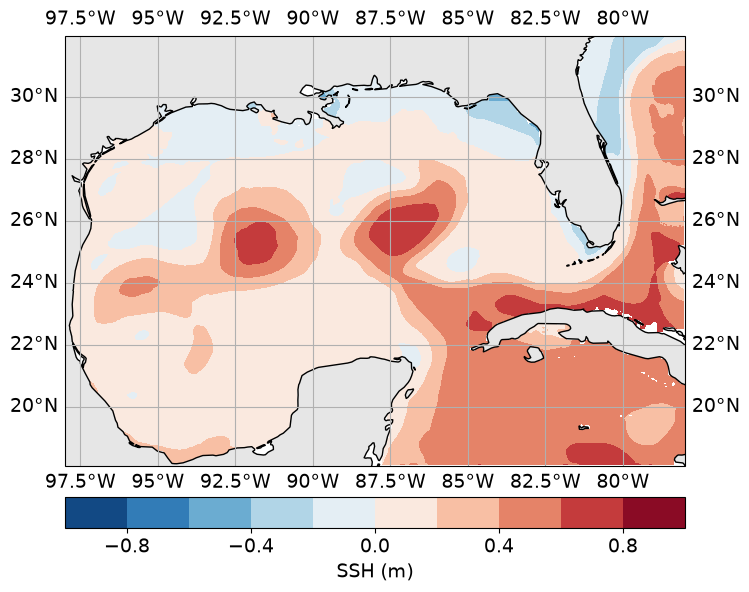

In [79]:
#exact same code as before
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, -78, lat_min, lat_max]) # note I also modified the lon_max here to cut off the white bit.

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9')
ax.add_feature(land_50m)

# let's fill in the following:
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# let's fill in the range here:
step = np.arange(-1, 1.1, 0.2)  # start, stop, step
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'RdBu_r', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.04)
cbar.set_label("SSH" +' (m)', size = 14)

ax.gridlines(draw_labels=True)

#### Not bad

## Lab 6.2

**E.0** Finish Lab 6.1 if you haven't already.

**E.1** Complete Introduction to Data Visualization with Matplotlib Chapters 3-4. Let me know if this feels like a good pace

#### This week, I focused on learning the new plots that I did not know exist and I could use them in my research

**E.2** Make notes for yourself on progamming tecniques and commands you learned in the lecture and datacamp chapter above, including examples, comments and explainitory text. You can do this here or in a separate notebook that you link to here. Basically, you are making a cheat sheet for yourself.

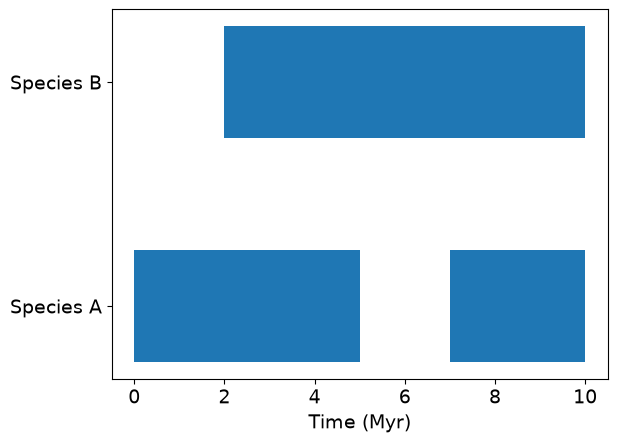

In [33]:
# Species A: from 0 to 5, then 7 to 10
plt.broken_barh([(0, 5), (7, 3)], (0, 1))

# Species B: from 2 to 10
plt.broken_barh([(2, 8)], (2, 1))          
plt.yticks([0.5, 2.5], ["Species A", "Species B"])
plt.xlabel("Time (Myr)")
plt.show()

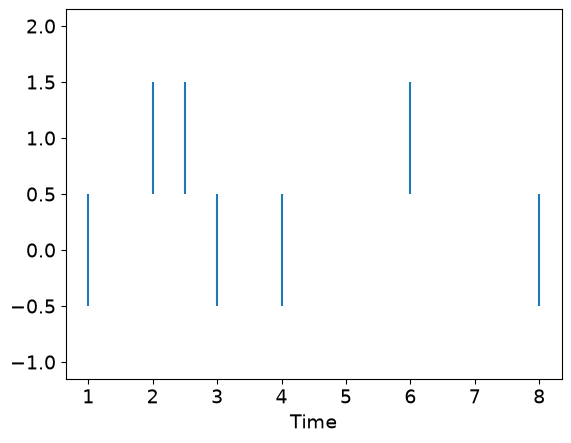

In [34]:
# using evenplots to show when events happened
plt.eventplot([[1, 3, 4, 8], [2, 2.5, 6]]) 
plt.xlabel("Time")
plt.show()

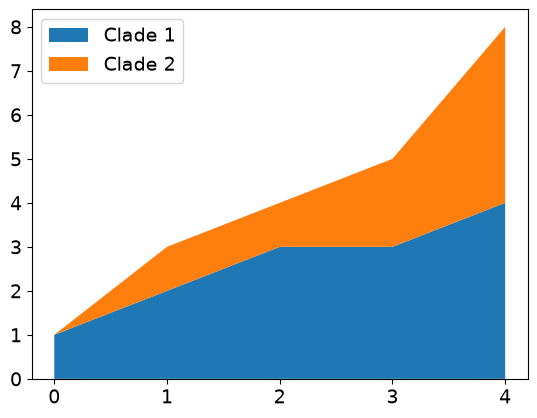

In [35]:
time = [0, 1, 2, 3, 4]
plt.stackplot(time, [1, 2, 3, 3, 4], [0, 1, 1, 2, 4],labels=["Clade 1", "Clade 2"])
plt.legend()
plt.show()

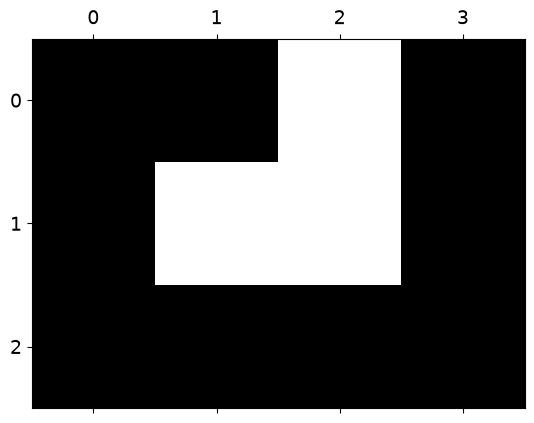

In [36]:
# spy plot can find where the data is present and where it is not.  # 1 = data, 0 = missing

alignment = np.array([[1, 1, 0, 1], [1, 0, 0, 1],[1, 1, 1, 1]])
plt.spy(alignment)
plt.show()

›**E.3** Make a plot of a different variable for the HYCOM data. Play around with colormaps and contourlines to make it your own. Post your plot on the class slack #programming channel

In [37]:
# looking at the variables available

list(gom_data.data_vars)

['surface_e_stress',
 'surface_n_stress',
 'ssh',
 'u_barotropic_velocity',
 'v_barotropic_velocity',
 'mixed_layer_thickness']

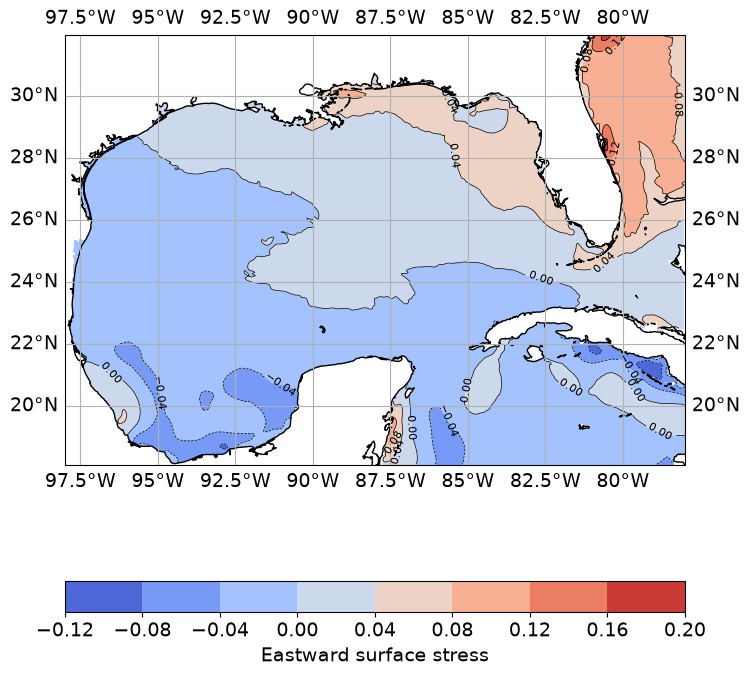

In [38]:
# making the map
fig, ax = plt.subplots(figsize=(8, 10), subplot_kw=dict(projection=ccrs.PlateCarree()))
# zooming in to the Gulf of Mexico
ax.set_extent([lon_min, -78, lat_min, lat_max])
# now drawing the coastline
ax.coastlines()
# picking the wind stress data and dropping the time dimension
var = gom_data.surface_e_stress[0, :, :]

p = ax.contourf(gom_data.Longitude, gom_data.Latitude, var,
                transform=ccrs.PlateCarree(), cmap='coolwarm')

# ax.contour draws the lines. If I do not write "f," it draws lines only. Plus, ax.clabel writes the values on the lines.

lines = ax.contour(gom_data.Longitude, gom_data.Latitude, var, colors="black", linewidths=0.5, transform=ccrs.PlateCarree())
ax.clabel(lines, fontsize=8)

plt.colorbar(p, orientation='horizontal', label='Eastward surface stress')
# adding the latitude and longitude label
ax.gridlines(draw_labels=True)
plt.show()

### This week's project:

#### Note you might want to restart your kernel at this point to dump all the hycom data from memory. Just reload the packages you need

**E.4** Download some data from the ISIMIP data archive (https://data.isimip.org/) and plot it using cartopy. ISIMIP provides bias-corrected data for past and future climate simulations used for impacts studies world wide. Let's start with some maximum atmospheric surface temperature data in the historical period (1850-2014 for CMIP6). We want climate forcing data for ISIMIP3b, which are the lastest (CMIP6) climate projections. 

* https://data.isimip.org/search/tree/ISIMIP3b/InputData/climate/
* Click atmopsheric forcing
* Click GFDL... This is one of NOAA-GFDL's climate models (ESM4)
* Click historical

All of the variable names are in CMIP lingo. Sadly, there is no easy cheat sheet. But you want tas, which is "temperature of air at surface". Let's use the tasmax, the maximum daily surface air temperature
* Click tasmax
* Click files to see all the available files.
  
Here you have a choice, you can download an etire file (note the size) or you can use the "configure download" button, which has subsetting by space or country, as well as time opitons. You can click on a file name to see more info.
* Click on "download file" for the 1851-1860 file. Just grab the whole file, it will take a minute to download.
* Load up the data into xarray and plot the maximum of this dataset (so max over the decade for each gridcell. You just use a max function for this, no loops needed).
* Plot using cartopy to make it pretty. Put some sensible lables on it, etc. Maybe add some country boundaries.

In [39]:
data = xr.open_dataset("/Users/sanaraza/Documents/OCS/Week6/ne_110m_coastline/gfdl-esm4_r1i1p1f1_w5e5_historical_tasmax_global_daily_1851_1860.nc")
data

<xarray.Dataset> Size: 4GB
Dimensions:  (time: 3653, lat: 360, lon: 720)
Coordinates:
  * time     (time) datetime64[ns] 29kB 1851-01-01 1851-01-02 ... 1860-12-31
  * lat      (lat) float64 3kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Data variables:
    tasmax   (time, lat, lon) float32 4GB ...
Attributes:
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...

In [40]:
data_max = data.tasmax.max(dim="time") - 273.15  
data_max
# .max(dim="time") actually squashes the 10 years of daily values into one number per grid per cell. Learnt about this here: https://docs.xarray.dev/en/latest/generated/xarray.DataArray.max.html

<xarray.DataArray 'tasmax' (lat: 360, lon: 720)> Size: 1MB
array([[  1.7390137,   1.7574768,   1.7298584, ...,   1.7771606,
          1.7550964,   1.7706299],
       [  1.5877075,   1.5904846,   1.5933838, ...,   1.6052551,
          1.5892029,   1.6009521],
       [  1.6297607,   1.648529 ,   1.6318359, ...,   1.6458435,
          1.6352539,   1.6413269],
       ...,
       [-15.035675 , -15.051392 , -15.039429 , ..., -15.028107 ,
        -15.015503 , -15.026184 ],
       [-13.8897705, -13.900543 , -13.866943 , ..., -13.958466 ,
        -13.932556 , -13.931274 ],
       [-14.85791  , -14.855957 , -14.8280945, ..., -14.910522 ,
        -14.872711 , -14.877228 ]], shape=(360, 720), dtype=float32)
Coordinates:
  * lat      (lat) float64 3kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    standard_name:  air_temperature
    long_name:      Daily Maximum Near-Surface Air Temperature
    units:          K

In [41]:
cfeature.BORDERS?

Type:           NaturalEarthFeature
String form:    <cartopy.feature.NaturalEarthFeature object at 0x167e69010>
File:           /opt/anaconda3/lib/python3.14/site-packages/cartopy/feature/__init__.py
Docstring:     
A simple interface to Natural Earth shapefiles.

See https://www.naturalearthdata.com/
Init docstring:
Parameters
----------
category
    The category of the dataset, i.e. either 'cultural' or 'physical'.
name
    The name of the dataset, e.g. 'admin_0_boundary_lines_land'.
scale
    The dataset scale, i.e. one of '10m', '50m', or '110m',
    or Scaler object. Dataset scales correspond to 1:10,000,000,
    1:50,000,000, and 1:110,000,000 respectively.

Other Parameters
----------------
**kwargs
    Keyword arguments to be used when drawing this feature.

In [42]:
plt.colorbar?

Signature:
plt.colorbar(
    mappable: 'ScalarMappable | ColorizingArtist | None' = None,
    cax: 'matplotlib.axes.Axes | None' = None,
    ax: 'matplotlib.axes.Axes | Iterable[matplotlib.axes.Axes] | None' = None,
    **kwargs,
) -> 'Colorbar'
Docstring:
Add a colorbar to a plot.

Parameters
----------
mappable
    The `matplotlib.colorizer.ColorizingArtist` (i.e., `.AxesImage`,
    `.ContourSet`, etc.) described by this colorbar.  This argument is
    mandatory for the `.Figure.colorbar` method but optional for the
    `.pyplot.colorbar` function, which sets the default to the current
    image.

    Note that one can create a `.colorizer.ColorizingArtist` "on-the-fly"
    to generate colorbars not attached to a previously drawn artist, e.g.
    ::

        cr = colorizer.Colorizer(norm=norm, cmap=cmap)
        fig.colorbar(colorizer.ColorizingArtist(cr), ax=ax)

cax : `~matplotlib.axes.Axes`, optional
    Axes into which the colorbar will be drawn.  If `None`, then a new
    Axes i

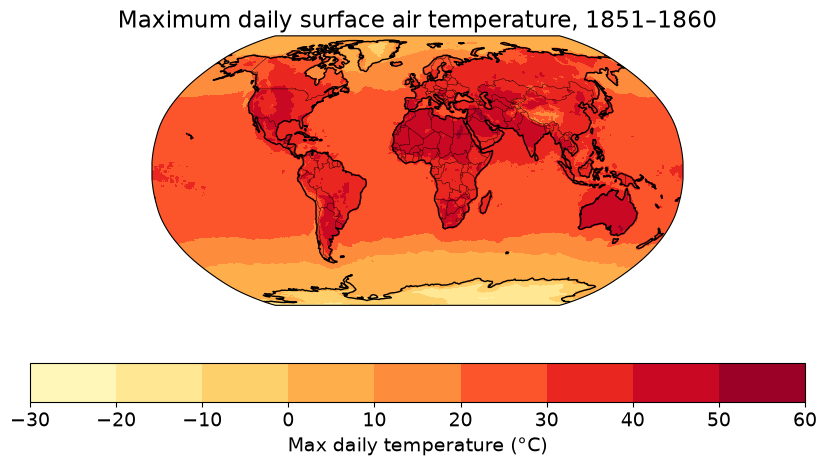

In [43]:
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=ccrs.Robinson()))
ax.coastlines()

# There are some attributes of country boundaries in here: https://cartopy.readthedocs.io/stable/reference/feature.html
# used this one: BORDERS which automatically scaled country boundaries.
ax.add_feature(cfeature.BORDERS, linewidth=0.3) 
p = ax.contourf(data_max.lon, data_max.lat, data_max,transform=ccrs.PlateCarree(), cmap="YlOrRd") # changing the color map from RdBu_r to YlOrRd to match the climate
plt.colorbar(p, orientation="horizontal", label="Max daily temperature (°C)")
plt.title("Maximum daily surface air temperature, 1851–1860")
plt.show()

**E.5** Now make a second plot using ISIMP data for a future climate projection. Following the same steps as above, get the GFDL tasmax data for the future climate scenario SSP3-7.0 (higher emissions scenario) for 2051-2060. Again, calculate the maximum at each gridpoint for this data set. This is the future maximum daily temperature for that decade. Make your plot nice.

In [44]:
future_dataset = xr.open_dataset("/Users/sanaraza/Documents/OCS/Week6/ne_110m_coastline/gfdl-esm4_r1i1p1f1_w5e5_ssp370_tasmax_global_daily_2051_2060.nc")
future_dataset

<xarray.Dataset> Size: 4GB
Dimensions:  (time: 3653, lat: 360, lon: 720)
Coordinates:
  * time     (time) datetime64[ns] 29kB 2051-01-01 2051-01-02 ... 2060-12-31
  * lat      (lat) float64 3kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Data variables:
    tasmax   (time, lat, lon) float32 4GB ...
Attributes:
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...

In [45]:
future_dataset_max = future_dataset.tasmax.max(dim="time") - 273.15  
future_dataset_max
# .max(dim="time") actually squashes the 10 years of daily values into one number per grid per cell. Learnt about this here: https://docs.xarray.dev/en/latest/generated/xarray.DataArray.max.html

<xarray.DataArray 'tasmax' (lat: 360, lon: 720)> Size: 1MB
array([[  2.19516  ,   2.1931458,   2.2062073, ...,   2.2049866,
          2.1987   ,   2.2044067],
       [  2.592041 ,   2.5665588,   2.6201172, ...,   2.4822388,
          2.5905457,   2.5124512],
       [  2.0246887,   2.0651855,   2.0151672, ...,   2.0516052,
          2.0255432,   2.0578918],
       ...,
       [-16.726776 , -16.474548 , -16.819    , ..., -16.431366 ,
        -16.694885 , -16.482727 ],
       [-13.003601 , -13.021271 , -12.983887 , ..., -13.038483 ,
        -13.014282 , -13.058014 ],
       [-17.72638  , -18.06752  , -17.661606 , ..., -18.14981  ,
        -17.85611  , -18.136337 ]], shape=(360, 720), dtype=float32)
Coordinates:
  * lat      (lat) float64 3kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    standard_name:  air_temperature
    long_name:      Daily Maximum Near-Surface Air Temperature
    units:          K

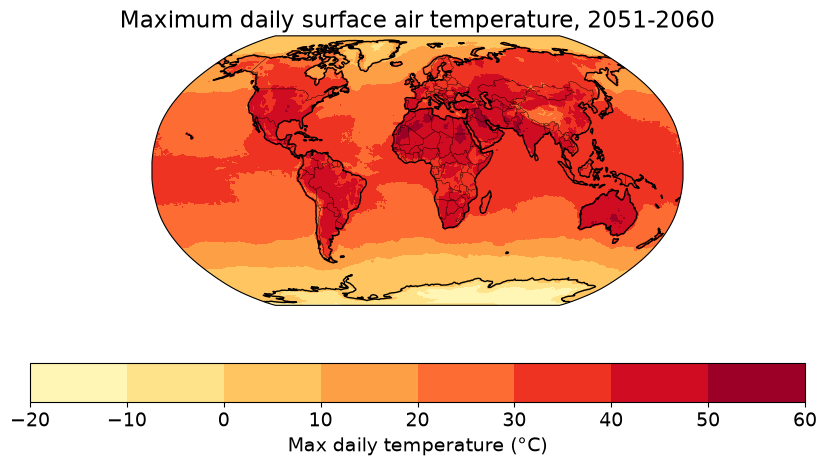

In [46]:
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=ccrs.Robinson()))
ax.coastlines()

# There are some attributes of country boundaries in here: https://cartopy.readthedocs.io/stable/reference/feature.html
# used this one: BORDERS which automatically scaled country boundaries.
ax.add_feature(cfeature.BORDERS, linewidth=0.3) 
p = ax.contourf(future_dataset_max.lon, future_dataset_max.lat, future_dataset_max,transform=ccrs.PlateCarree(), cmap="YlOrRd") # changing the color map from RdBu_r to YlOrRd to match the climate
plt.colorbar(p, orientation="horizontal", label="Max daily temperature (°C)")
plt.title("Maximum daily surface air temperature, 2051-2060")
plt.show()

**E.6** Now plot the anomaly between the two, 2050's - 1850's. Use a diverging colormap (light in the middle), centered on zero. What is the outlook for your country of orgin? Answer in full sentances with specific numbers.

1.7366158962249756


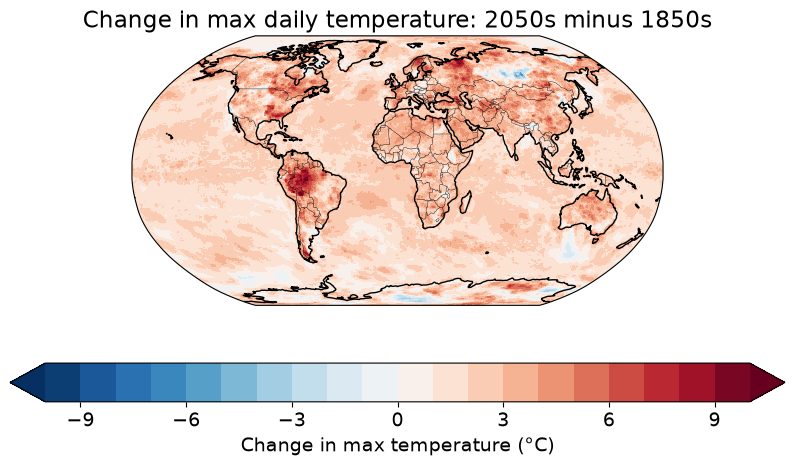

In [47]:
# just subtracting the future dataset with the current one
anomaly = future_dataset_max - data_max
print(float(anomaly.mean()))   

fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=ccrs.Robinson()))
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

# levels from -10 to 10, so 0 is in the middle 
p = ax.contourf(anomaly.lon, anomaly.lat, anomaly, transform=ccrs.PlateCarree(), cmap="RdBu_r", extend='both', levels=np.arange(-10, 11, 1))

plt.colorbar(p, orientation="horizontal", label="Change in max temperature (°C)")
plt.title("Change in max daily temperature: 2050s minus 1850s")
plt.show()

In [48]:
# My city is karachi, Pakistan. Found the latitude and longitude from Google
lat, lon = 24.86, 67.01

past   = float(data_max.sel(lat=lat, lon=lon, method="nearest"))
future = float(future_dataset_max.sel(lat=lat, lon=lon, method="nearest"))
change = float(anomaly.sel(lat=lat, lon=lon, method="nearest"))

print("1850s max temperature:", round(past, 1), "°C")
print("2050s max temperature:", round(future, 1), "°C")
print("Change:", round(change, 1), "°C")

1850s max temperature: 41.3 °C
2050s max temperature: 44.9 °C
Change: 3.6 °C


Under the SSP3-7.0 (higher emissions) scenario, the GFDL-ESM4 model projects, the maximum temperature would rise from 41.3 °C in the 1850s (1851–1860) to about 44.9 °C in the 2050s (2051–2060). That is an increase of about 3.6 °C temperature.  This also means that the hottest days in Karachi will become noticeably more extreme. This could increase the risk of heatwaves.

**E.7** How could you potentially use this kind of data (future climate projections) in your research? Do some brainstorming. Write down your thoughts here.

##### I work in evolutionary biology and work with phylogenetic trees. Hence, I do not think so I would be using this kind of the dataset. But in rare cases, I could use the future temperature projections to find out which species in my trees are under very high extinction risk. Secondly, I can also use the tools like xarray, cartopy to find out whether the past climate data is in line with the bursts of speciation on a phylogeny. 
    